<h1> HW 2: Radar Imaging Part 3a</h1>


<h3> 3. 3D Imaging using 2D Antenna Array </h3>

This task includes two parts. Our goal is to implement radar signal processing for 3D imaging
using a 2D antenna array. You will implement two algorithms we taught in the class. 

<h5> 3.1 Algorithm 1 - Conventional Beam Forming </h5>

In this part, we will need to image the scene using Algorithm 1 we taught in class for a 2D antenna array. You will generate the 3D radar heatmap by estimating the
reflected signal power from every azimuth angles $\phi$ - elevation angles $\theta$ pair. Every azimuth
angle and elevation angle, along with the range will pinpoint a 3D voxel in the spherical
coordinates. To speed up the alogrithm, you can crop the range bins to be from 100 to 120 instead of using all 512 range bins.
The code for this task should be written in the functions *beamform_2d* defined below. We provide you
the code to load the radar data in the right format and to plot the 3D heatmap in this
file.

As results, you need to include the following in your report.
1. Generate a 3D heatmap for azimuth angle $\phi$ between 60 and 130 degrees with a resolution
of 1 degree, and elevation angle $\theta$ between 70 and 110 degrees with a resolution of 1 degrees. The
definition for $\phi$ and $\theta$ can be found in Fig. 1. Include the top view, side view, and
front view projections of the 3D heatmap in the spherical coordinates, as well as a
3D point cloud by setting a threshold on the heatmap and selecting the points with a
reflection power above this threshold. Examples of this plotting code is shown at the bottom of the file.

2. Generate the above 3D heatmaps and point clouds for all data provided. 

Write your algorithm below.

In [161]:
################# Change the values based on how much of the azimuth angles you want to see and the resolution ##################
# Define field of view in degrees that you want to process in theta, phi and range bins
def beamform_2d(beat_freq_data, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_locs, z_locs, r_idxs, radar_params):
    """
    Performs 2D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num_z_stps * num TX * num RX, num ADC samples)
    - phi_s: first azimuth angle that you want to start computing 
    - phi_e: last azimuth angle that you want to compute 
    - phi_res: resolution of the azimuth angles you want to compute
    - theta_s: first elevation angle that you want to start computing 
    - theta_e: last elevation angle that you want to compute 
    - theta_res: resolution of the elevation angles you want to compute
    - x_locs: x coordinate of antenna locations
    - z_locs: z coordinate of antenna locations
    - r_idx: range bins to calculate 
    - radar_parms: radar_params if needed 

    Returns:
    - sph_pwr: beamformed result (size: n_phi, n_theta, n_range)
    - phi: array of azimuth angles 
    - theta: array of elevation angles 
    """

    # Radar parameters
    sample_rate = radar_params["sample_rate"]
    num_samples = radar_params["num_samples"]
    slope = radar_params["slope"]
    lm = radar_params["lm"]
    num_z_stp = radar_params["num_z_stp"]
    num_tx = radar_params["num_tx"]
    num_rx = radar_params["num_rx"]
    adc_samples = radar_params["adc_samples"]

    # Convert angles to radians
    phi = np.arange(phi_s, phi_e, phi_res) * np.pi / 180 
    theta = np.arange(theta_s, theta_e, theta_res) * np.pi / 180
    num_theta = len(theta)
    num_phi = len(phi)

    # Initialize output
    sph_pwr = np.zeros((num_phi, num_theta, r_idxs.shape[0]), dtype=np.complex64)
    
    for i, angle_phi in enumerate(phi):
        print(i)
        for j, angle_theta in enumerate(theta):
            # Compute angles
            angles = x_locs * np.sin(angle_theta) * np.cos(angle_phi) +  z_locs * np.cos(angle_theta)
            # Compute phase shifts
            phase_shifts = np.exp((1j * 2 * np.pi / lm) * angles)
       
            # Apply phase shifts
            beamformed_signal = beat_freq_data * phase_shifts[:,:, np.newaxis]
        
            # Compute sph
            sph_pwr[i, j, :] = np.abs(np.sum(np.sum(beamformed_signal, axis=0), axis=0))

    print(sph_pwr.shape)
    return sph_pwr, phi, theta 

In [162]:

import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import open3d as o3d
import utils

import numba
from numba import njit, prange

Load data.

In [187]:
# TODO: Put the *path* to the project folder
data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/COM-304-Radars/homework/data/data_003_.mat'

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Defining antenna positions. 

In [188]:
x_ant_pos, z_pos, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

Process raw data for BF algorthim (use all samples now).

In [189]:
# TODO: reshape raw_data and process beat frequency
beat_freq = np.fft.fft(raw_data)

Define the angles and range bins to run, and run the BF algo.

In [190]:
# define the azimuth angles (horizontal FOV) that we want to look at 
r_idxs = np.arange(100, 140) # TODO: Change to distance rather than range bins
phi_s, phi_e = 60, 130 
phi_res = 1
theta_s, theta_e = 70,110 
theta_res = 1

# Run your algorithm here
# TODO: input arguments that you choose
bf_output1, phi, theta= beamform_2d(beat_freq[:, :,r_idxs], phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_ant_pos, z_pos, r_idxs, radar_params)

# Save the output
np.save('./data/homework_2/beamforming_2d_output/bf_output_003.npy', bf_output1)
np.save('./data/homework_2/beamforming_2d_output/phi_003.npy', phi)
np.save('./data/homework_2/beamforming_2d_output/theta_003.npy', theta)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
(70, 40, 40)


In [1]:
# Load the output
bf_output1 = np.load('./data/homework_2/beamforming_2d_output/bf_output_010.npy')
phi = np.load('./data/homework_2/beamforming_2d_output/phi_010.npy')
theta = np.load('./data/homework_2/beamforming_2d_output/theta_010.npy')

NameError: name 'np' is not defined

Here you should plot the outputs from beamforming.

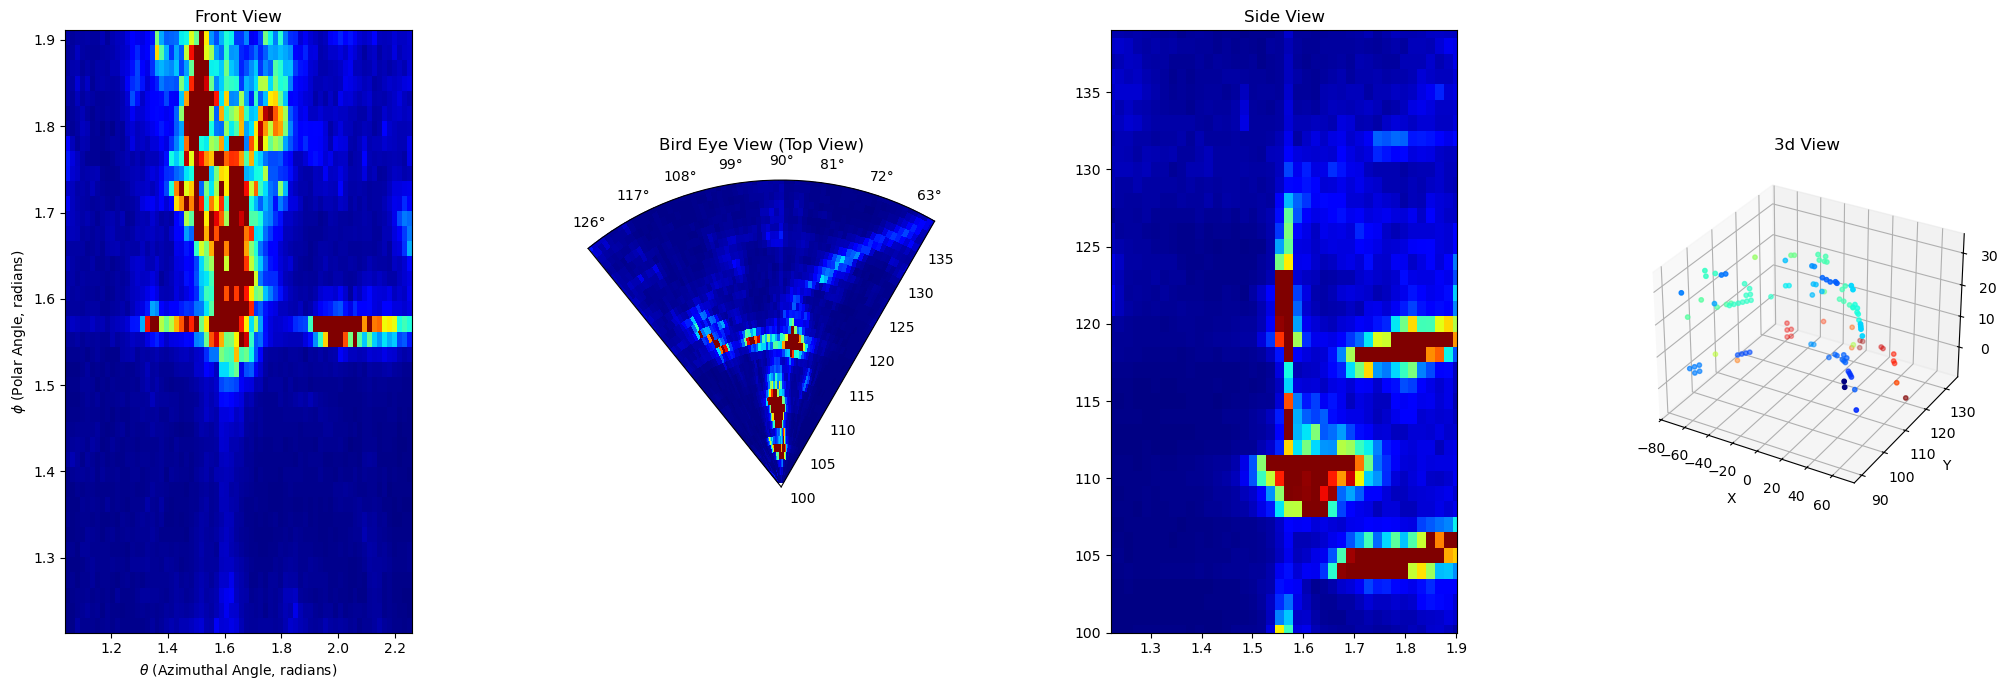

In [199]:
# Plot the output from 2D Beamforming (You can change this as you see fit)
fig = plt.figure(figsize=(20, 7))

to_plot = np.sum(abs(bf_output1),axis=-1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax0 = fig.add_subplot(141)
utils.plot_2d_polar_heatmap(ax0, to_plot, phi, theta, vmin=0, vmax=0.1)
ax0.title.set_text('Front View')

to_plot = np.sum(abs(bf_output1),axis=1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax1 = fig.add_subplot(142,projection = 'polar')
utils.plot_2d_heatmap(ax1, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
ax1.title.set_text('Bird Eye View (Top View)')

to_plot = np.sum(abs(bf_output1),axis=0)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax2 = fig.add_subplot(143)
utils.plot_2d_heatmap(ax2, to_plot, theta, r_idxs, vmin=0, vmax=0.1)
ax2.title.set_text('Side View')

to_plot = bf_output1
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax3 = fig.add_subplot(144, projection = '3d')
utils.plot_3d_polar_heatmap(ax3, to_plot, phi, theta, r_idxs, 0.1)
ax3.title.set_text('3d View')



plt.tight_layout()
plt.show()

<h1> HW 2: Radar Imaging Part 3b</h1>


<h5> 3.b Algorithm 3 - Matched Filter </h5>

In this part, we will need to image the scene using Algorithm 3 we taught in class for a 2D antenna array. You will generate the 3D radar heatmap by estimating
the reflected signal power from every voxel in the 3D cartesian coordinates (x,y,z).
The code for this task should be written in the function matched_filter_2d. We provide you
the code to load the radar data in the right format and to plot the heatmap in this
file. Though the MF output can be 3D, because of compute time, we ask that you just show a single depth slice of the scene making the output 2D.

As results, you need to include the following in your report: 
1. Generate the heatmap for all 3 scenes given
in the cartesian coordinates. The space of interest is indicated in Data Details in the google drive. The spatial resolution
should be 0.01 for x and z. Plot the front view.

2. Compare the heatmaps with the corresponding one from Task 3a, and comment on
the differences.

Notes: 
- Running matched filter code in Python can be slow. 
- And remember to check parameter clim to get reasonable heatmaps. 


In [3]:
from numba import njit, prange

In [4]:
######## 2D Imaging in Cartesian #############
#@njit(parallel=True, fastmath=True)
@njit(fastmath=True, parallel=True)
def matched_filter_2d(raw_data_2d, x_grid, z_grid, y_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, lm, ts, slope, c, MF_output):
    """
    Performs 2D matched filter on the raw data.
    - raw_data_2d: raw data  
    - num_x_cells: x axis values (azimuth)
    - num_z_cells: z axis values (elevation)
    - num_y_cells: y axis values (range)
    - x_radar_tx: transmitter positions (x) 
    - x_radar_rx: receiver positions (x)
    - z_radar_tx: transmitter positions (z)
    - z_radar_rx: receiver positions (z)
    
    Returns:
    - MF_output: matched filter output (size: num_x_cells x num_y_cells  x num_z_cells aka azimuth, depth, elevation)
    """

    # Constants
    #c = 3e8  # Speed of light

    # Initialize output
    #MF_output = np.zeros((len(x_grid), len(z_grid), len(y_grid)), dtype=np.complex64)
    #print(len(x_grid)*len(y_grid)*len(z_grid)*len(x_radar_tx)*len(z_radar_tx)*len(ts))


    for x_i in prange(len(x_grid)):  # Parallel execution on the outer loop
        x = x_grid[x_i]
        for z_i in prange(len(z_grid)):  # Parallel execution
            z = z_grid[z_i]
            for y_i in range(len(y_grid)):  # Keep inner loops serial for cache efficiency
                y = y_grid[y_i]
                for m in range(len(x_radar_tx)):
                    for k_i in range(len(z_radar_tx)):
                        for t_i in range(len(ts)):
                            tt = ts[t_i]

                            # Compute distances
                            distances_rx = np.sqrt((x - x_radar_rx[m])**2 + y**2 + (z - z_radar_rx[k_i])**2)
                            distances_tx = np.sqrt((x - x_radar_tx[m])**2 + y**2 + (z - z_radar_tx[k_i])**2)
                            distances = distances_rx + distances_tx

                            # Compute phase
                            phase_shifts = np.exp(-1j * 2 * np.pi * (slope*tt / c + 1 / lm) * distances)

                            # Apply matched filter
                            MF_output[x_i, z_i, y_i] += np.sum(raw_data_2d[m, k_i, t_i] * phase_shifts)

    return MF_output

Implement your matched filter algortihm below. If you would like to speed up processing time you can try to optimize code --> (eg. Numba, multiprocessing,), additionlly for debugging we recommend processing lower resolution.

Additionally, you may move away from a Jupyter Notebook for this task only if you find that optmizing the code requires this. However, please attach the plots in a PDF in addition to plotting the output in your code if you follow this path.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.io as sio
import time
import open3d as o3d
import helpers 
import utils

Load data.

In [3]:
# TODO: Put the *path* to the project folder
data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/COM-304-Radars/homework/data/data_Tim/rdc_hand.mat'

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)
lm = radar_params["lm"]
slope = radar_params["slope"]

Defining antenna positions.

In [4]:
x_ant_pos, z_ant_pos, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

Process raw data for MF algorthim (use all samples now).

In [5]:
X = raw_data.reshape(12, 499, 512)

ValueError: cannot reshape array of size 3059712 into shape (12,499,512)

Define the x,y,z voxels to calculate and the radars transmitter and receiver positions in x and z. Then run your algorithm. We recommend processing at lower resolution (eg. 0.05) or smaller portions of space for debugging.

In [152]:
# Define the grid
res = 0.01
x_max = 0.22
x_min = -0.23
x_grid = np.arange(x_min, x_max, res)

z_max = 0.24
z_min = -0.185
z_grid = np.arange(z_min, z_max, res)

y_grid = np.arange(4.45, 4.46, 0.01)

# Define the time samples
t = np.arange(100, 120)/radar_params["sample_rate"]

x_radar_tx = np.repeat(x_ant, 4)
x_radar_rx = x_ant_pos
z_radar_tx = z_ant_pos.reshape(369)
z_radar_rx = z_ant_pos.reshape(369)

# Initialize output
MF_output = np.zeros((len(x_grid), len(z_grid), len(y_grid)), dtype=np.complex64)

# Run matched filter algorithm
MF_output = matched_filter_2d(X, x_grid, z_grid, y_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, lm, t, slope, 3e8, MF_output)

# Save the output
#np.save('./data/homework_2/matched_filter_2d_output/MF_output_010.npy', MF_output)

In [153]:
# Load the output
MF_output_003 = np.load('./data/homework_2/matched_filter_2d_output/tim_data.npy')

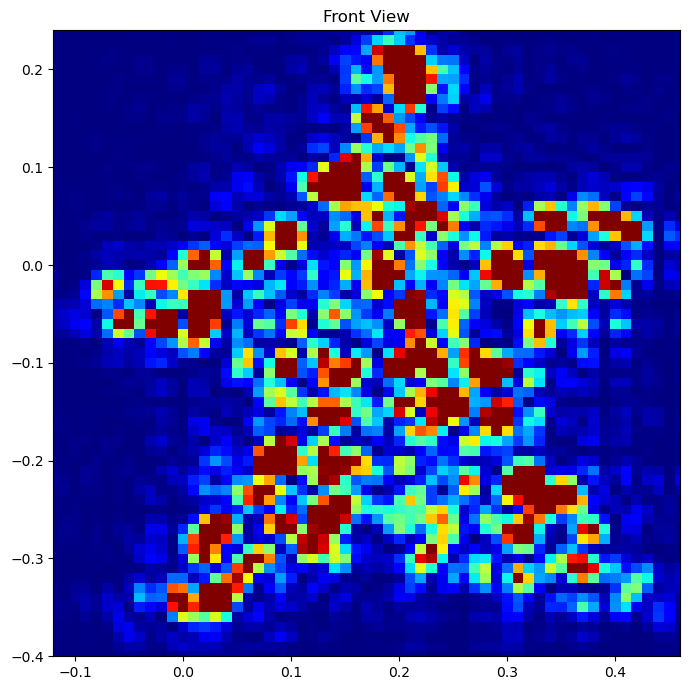

In [201]:
# Define the grid
res = 0.01
x_max = 0.46
x_min = -0.12
x_grid = np.arange(x_min, x_max, res)

z_max = 0.25
z_min = -0.40
z_grid = np.arange(z_min, z_max, res)

# Plot the output from MF (You can change this as you see fit (this will just plot the front of the object as we are not processing the entire heatmap)
fig = plt.figure(figsize=(7, 7))
MF = MF_output_003
to_plot = np.sum(abs(MF),axis=-1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax0 = fig.add_subplot(111)
utils.plot_2d_heatmap(ax0, to_plot, x_grid, z_grid, vmin=0, vmax=0.1)
ax0.title.set_text('Front View')

plt.tight_layout()
plt.show()

Plot your outputs below.